# Raw Data Distributions for M1, M2, M3, M4, and M7

This notebook loads the saved raw simulation datasets from `ood_20d_10n` and plots the distribution of the raw observations `x`.

Each model has 50 datasets, each with shape `(10, 20)`. The plots below flatten all raw `x` values within each model.


In [1]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


project_dir = Path("/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian")
dataset_dir = project_dir / "results" / "ood_20d_10n" / "datasets"
figure_dir = project_dir / "figures" / "raw_data_distributions"
figure_dir.mkdir(parents=True, exist_ok=True)

models = ("m1", "m2", "m3", "m4", "m7")
model_colors = {
    "m1": "#B8AC0A",
    "m2": "#3C0CFF",
    "m3": "#000000",
    "m4": "#FA6502",
    "m7": "#717A7F",
}

plt.rcParams.update({
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "figure.dpi": 120,
})


In [2]:
def load_raw_model(model):
    with open(dataset_dir / f"{model}_raw.pkl", "rb") as f:
        return pickle.load(f)


raw_data = {model: load_raw_model(model) for model in models}
x_values = {
    model: np.concatenate([np.asarray(item["x"]).ravel() for item in data])
    for model, data in raw_data.items()
}

summary = pd.DataFrame({
    model.upper(): {
        "n_values": len(values),
        "mean": values.mean(),
        "std": values.std(ddof=1),
        "min": values.min(),
        "q025": np.quantile(values, 0.025),
        "median": np.median(values),
        "q975": np.quantile(values, 0.975),
        "max": values.max(),
    }
    for model, values in x_values.items()
}).T

summary


,n_values,mean,std,min,q025,median,q975,max
M1,10000.0,-0.030607,1.414246,-5.112174,-2.801860,-0.016313,2.706553,5.712957
M2,10000.0,3.022796,1.398147,-2.464935,0.265701,3.023493,5.760305,8.211985
M3,10000.0,-0.043244,3.153251,-11.985586,-6.357599,-0.029450,6.118736,12.996188
M4,10000.0,0.049180,1.419388,-6.053459,-2.723307,0.057698,2.802263,4.768849
M7,10000.0,-0.163266,5.091483,-21.651394,-10.182378,-0.116397,9.842627,20.379600


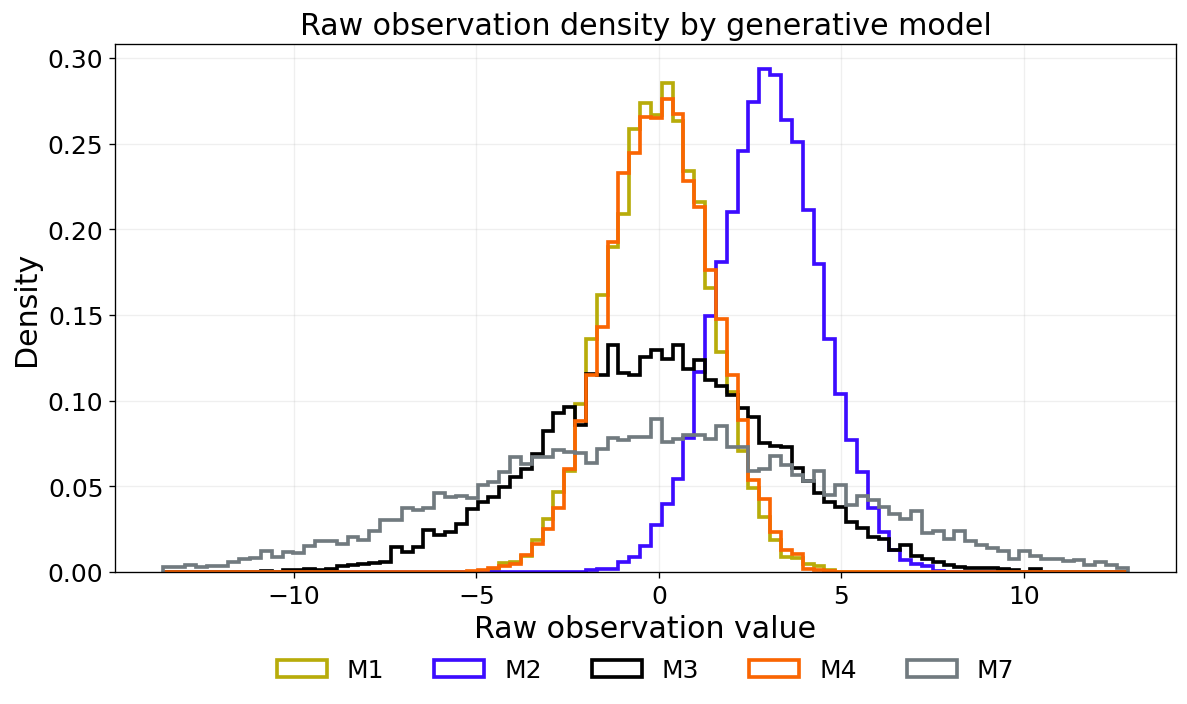

In [3]:
all_values = np.concatenate(list(x_values.values()))
bins = np.linspace(np.quantile(all_values, 0.001), np.quantile(all_values, 0.999), 90)

fig, ax = plt.subplots(figsize=(10, 6))
for model, values in x_values.items():
    ax.hist(
        values,
        bins=bins,
        density=True,
        histtype="step",
        linewidth=2.2,
        color=model_colors[model],
        label=model.upper(),
    )

ax.set_title("Raw observation density by generative model")
ax.set_xlabel("Raw observation value")
ax.set_ylabel("Density")
ax.grid(alpha=0.2)
ax.legend(frameon=False, ncol=len(models), loc="upper center", bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()
fig.savefig(figure_dir / "raw_x_density_overlay_m1_m2_m3_m4_m7.png", dpi=220, bbox_inches="tight")


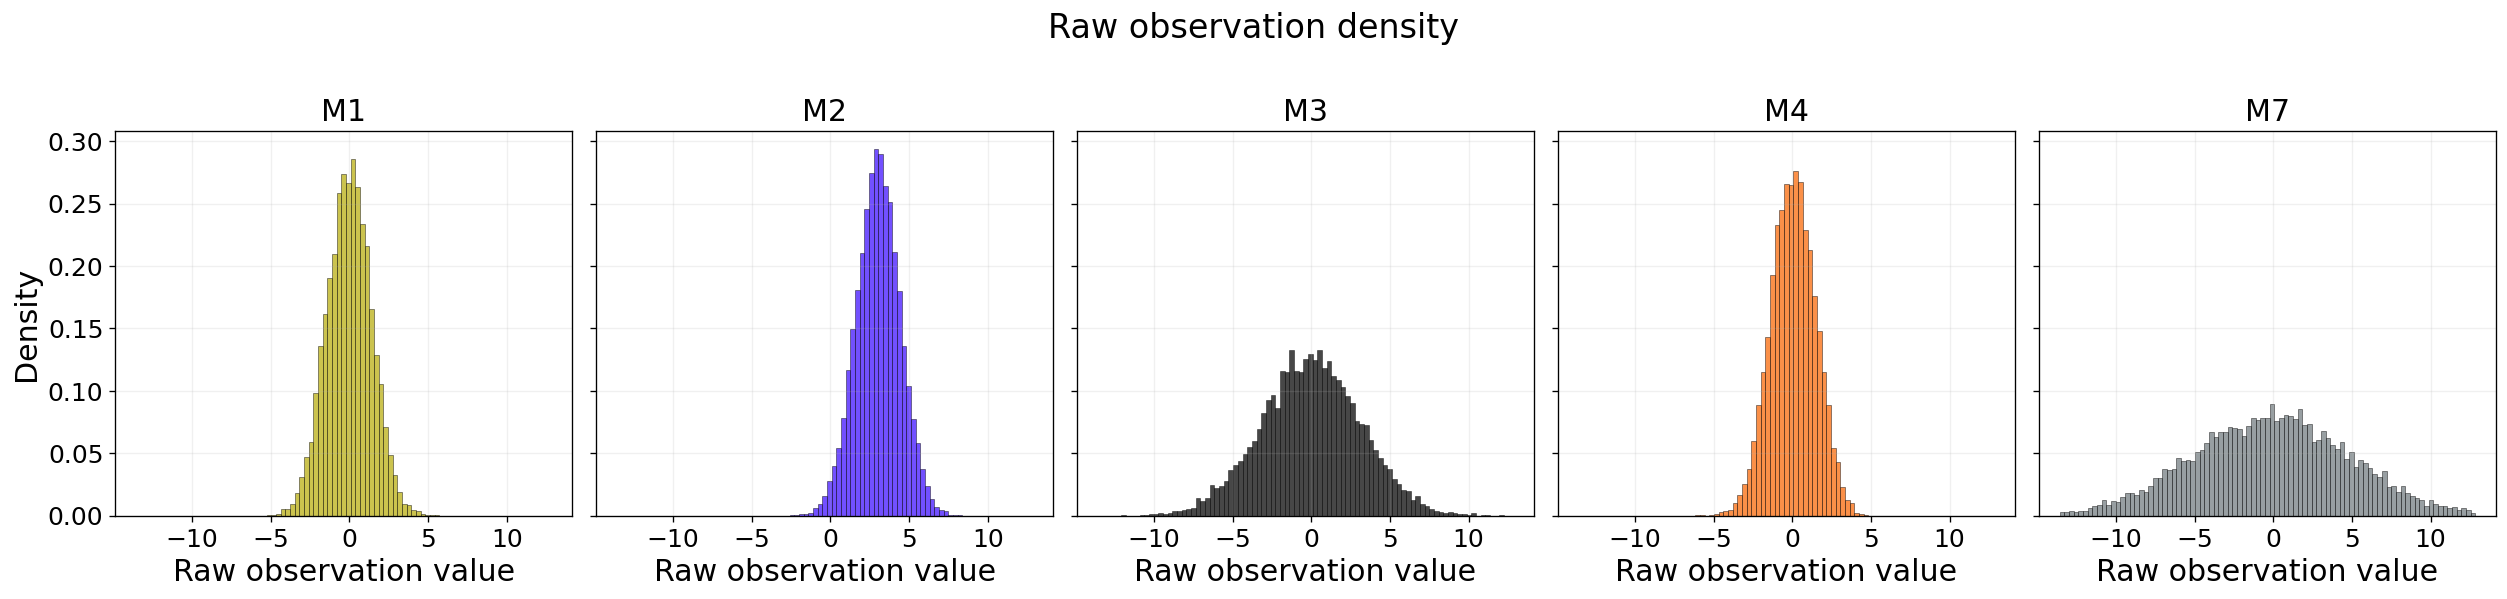

In [4]:
fig, axes = plt.subplots(1, len(models), figsize=(4.2 * len(models), 4.8), sharey=True)

for ax, model in zip(axes, models, strict=False):
    ax.hist(
        x_values[model],
        bins=bins,
        density=True,
        color=model_colors[model],
        alpha=0.72,
        edgecolor="black",
        linewidth=0.35,
    )
    ax.set_title(model.upper())
    ax.set_xlabel("Raw observation value")
    ax.grid(alpha=0.18)

axes[0].set_ylabel("Density")
fig.suptitle("Raw observation density", y=1.03, fontsize=20)
fig.tight_layout()
fig.savefig(figure_dir / "raw_x_density_facets_m1_m2_m3_m4_m7.png", dpi=220, bbox_inches="tight")


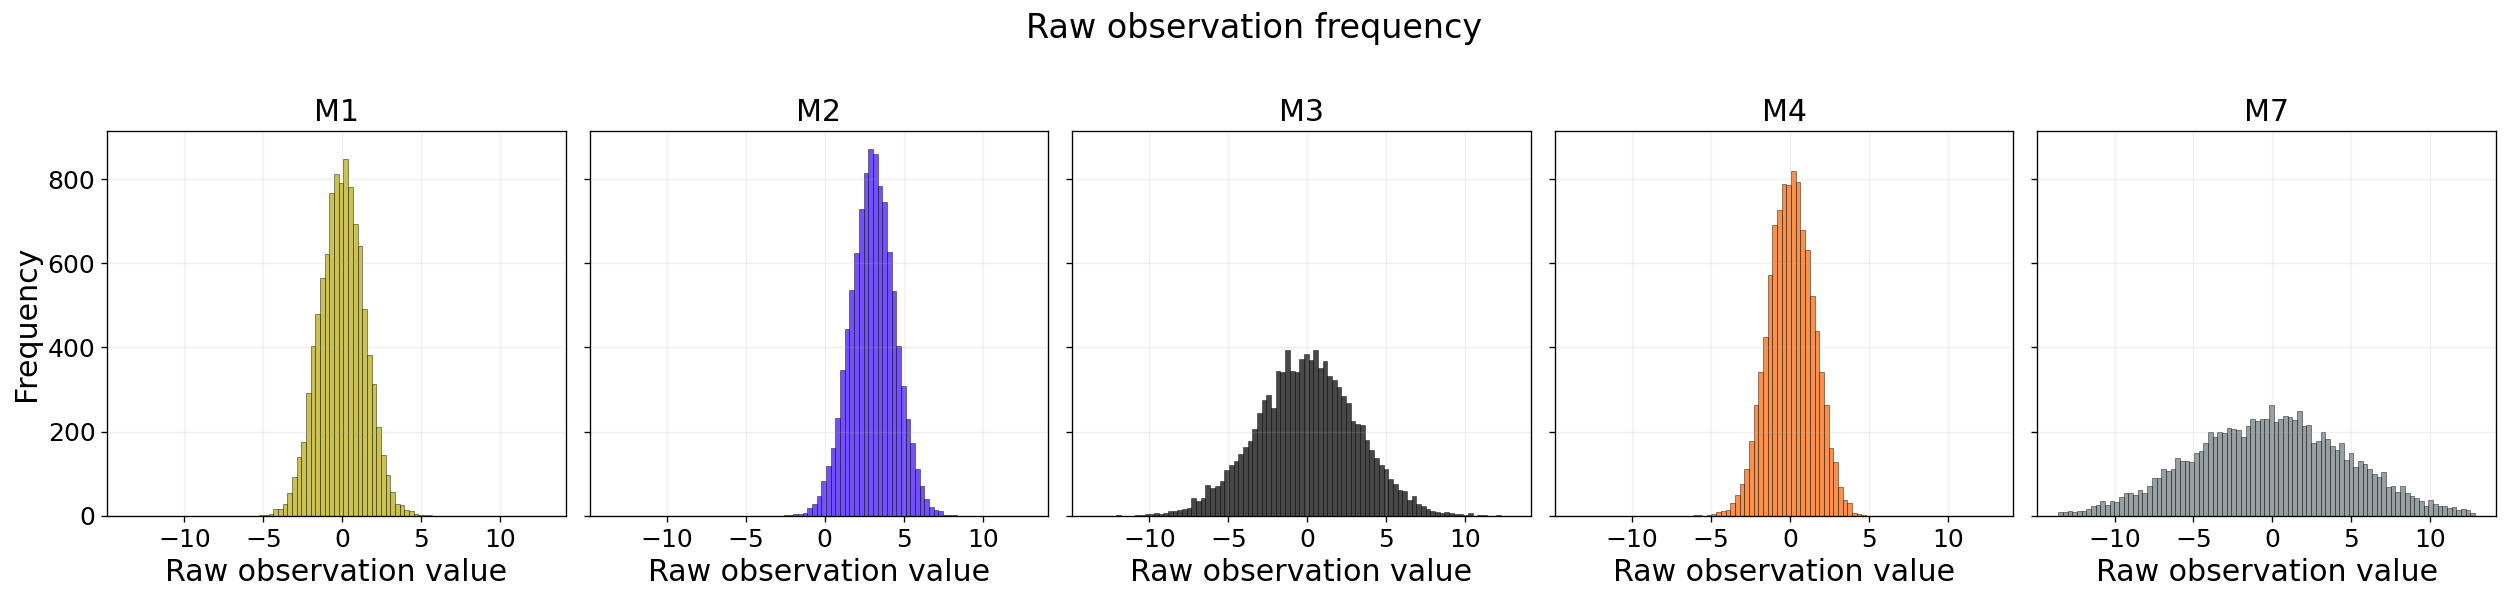

In [5]:
fig, axes = plt.subplots(1, len(models), figsize=(4.2 * len(models), 4.8), sharey=True)

for ax, model in zip(axes, models, strict=False):
    ax.hist(
        x_values[model],
        bins=bins,
        density=False,
        color=model_colors[model],
        alpha=0.72,
        edgecolor="black",
        linewidth=0.35,
    )
    ax.set_title(model.upper())
    ax.set_xlabel("Raw observation value")
    ax.grid(alpha=0.18)

axes[0].set_ylabel("Frequency")
fig.suptitle("Raw observation frequency", y=1.03, fontsize=20)
fig.tight_layout()
fig.savefig(figure_dir / "raw_x_frequency_facets_m1_m2_m3_m4_m7.png", dpi=220, bbox_inches="tight")


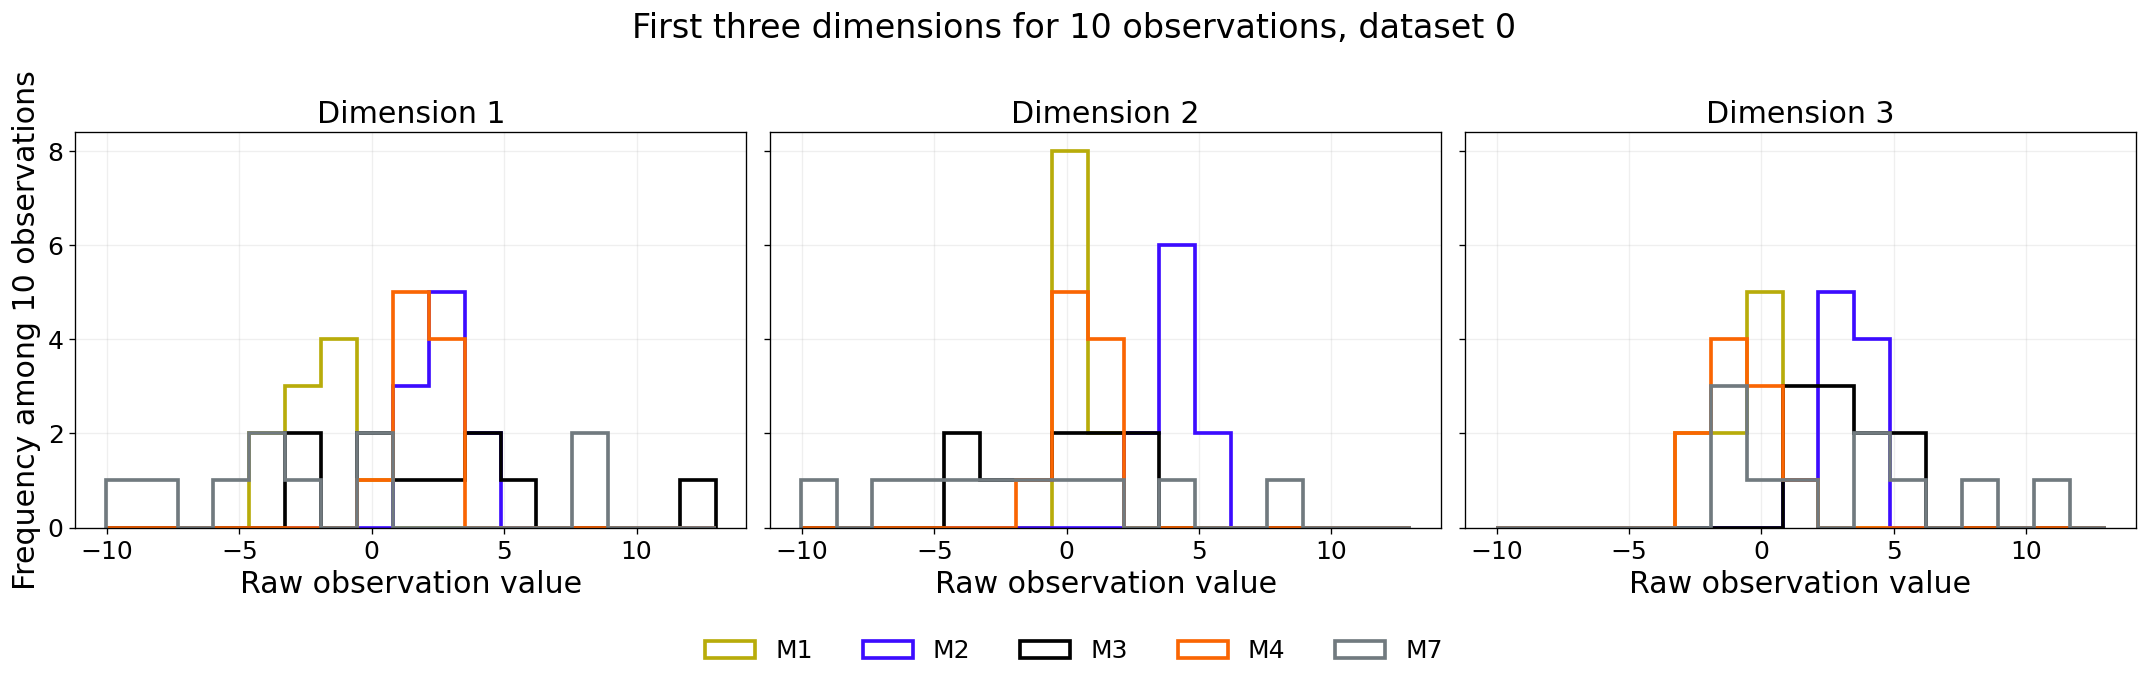

In [6]:
# First three dimensions for the 10 observations in one raw dataset per model.
# dataset_index=0 means we use raw_data[model][0]["x"], whose shape is (10, 20).
dataset_index = 0


def first_three_dims_for_dataset(data, dataset_index=0):
    return np.asarray(data[dataset_index]["x"])[:, :3]


first3_values = {
    model: first_three_dims_for_dataset(raw_data[model], dataset_index=dataset_index)
    for model in models
}

all_first3 = np.concatenate([values.ravel() for values in first3_values.values()])
first3_bins = np.linspace(all_first3.min(), all_first3.max(), 18)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), sharey=True)
for dim, ax in enumerate(axes):
    for model in models:
        ax.hist(
            first3_values[model][:, dim],
            bins=first3_bins,
            density=False,
            histtype="step",
            linewidth=2.2,
            color=model_colors[model],
            label=model.upper() if dim == 0 else None,
        )
    ax.set_title(f"Dimension {dim + 1}")
    ax.set_xlabel("Raw observation value")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Frequency among 10 observations")
fig.suptitle(f"First three dimensions for 10 observations, dataset {dataset_index}", y=1.03, fontsize=20)
fig.legend(frameon=False, ncol=len(models), loc="lower center", bbox_to_anchor=(0.5, -0.05))
fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.savefig(figure_dir / "raw_x_first_dataset_10obs_first_three_dimensions.png", dpi=220, bbox_inches="tight")

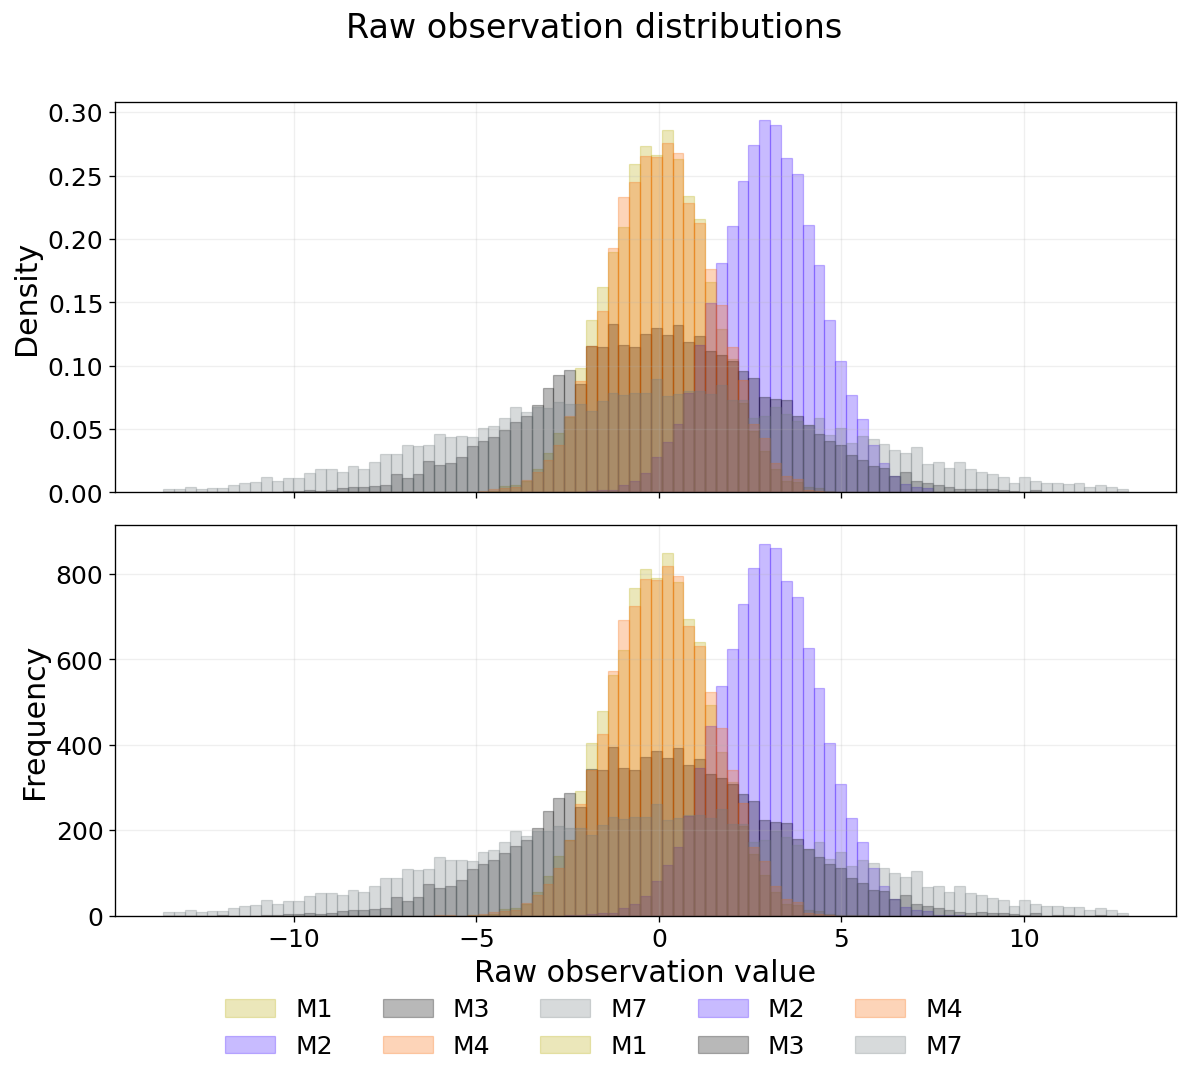

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

for model in models:
    axes[0].hist(
        x_values[model],
        bins=bins,
        density=True,
        color=model_colors[model],
        alpha=0.28,
        edgecolor=model_colors[model],
        linewidth=0.75,
        label=model.upper(),
    )
    axes[1].hist(
        x_values[model],
        bins=bins,
        density=False,
        color=model_colors[model],
        alpha=0.28,
        edgecolor=model_colors[model],
        linewidth=0.75,
        label=model.upper(),
    )

axes[0].set_ylabel("Density")
axes[1].set_ylabel("Frequency")
axes[1].set_xlabel("Raw observation value")
for ax in axes:
    ax.grid(alpha=0.2)

fig.suptitle("Raw observation distributions", y=0.98, fontsize=20)
fig.legend(frameon=False, ncol=len(models), loc="lower center", bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=(0, 0.06, 1, 0.96))
fig.savefig(figure_dir / "raw_x_density_and_frequency_overlay_m1_m2_m3_m4_m7.png", dpi=220, bbox_inches="tight")

In [8]:
print(f"Saved figures to: {figure_dir}")
for path in sorted(figure_dir.glob("raw_x_*.png")):
    print(path.name)

Saved figures to: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/figures/raw_data_distributions
raw_x_density_and_frequency_facets_m1_m2_m3_m4_m7.png
raw_x_density_and_frequency_overlay_m1_m2_m3_m4_m7.png
raw_x_density_facets_m1_m2_m3_m4_m7.png
raw_x_density_overlay_m1_m2_m3_m4_m7.png
raw_x_first_dataset_10obs_first_three_dimensions.png
raw_x_first_three_dimensions_density_overlay.png
raw_x_frequency_facets_m1_m2_m3_m4_m7.png
